# Waterfilling Levels

In [1]:
import sys
sys.path.insert(1, '../../functions')
import importlib
import numpy as np
import nbformat
import plotly.express
import plotly.express as px
import pandas as pd
import scipy.optimize as optimization
import food_bank_functions
import food_bank_bayesian
import matplotlib.pyplot as plt
import seaborn as sns
from food_bank_functions import *
from food_bank_bayesian import *
importlib.reload(food_bank_functions)

<module 'food_bank_functions' from '../../functions\\food_bank_functions.py'>

### Generating Distribution

In [2]:
lam = 10
num_bins = 26
samples = np.random.poisson(lam,100000)

In [3]:
print(samples)
min_samples = np.floor(min(samples))
max_samples = np.ceil(max(samples))
print(min_samples, max_samples)

[ 7 12 12 ... 10 10  7]
0.0 27.0


In [4]:
bins = np.digitize(samples, np.arange(min_samples+1, max_samples+1))
support = np.arange(min_samples+1, max_samples+1)
support = np.append(support, max(samples))
print(support)
vals = np.zeros(len(support))

for i in bins:
    vals[i] += 1
vals = vals / np.sum(vals)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 27.]


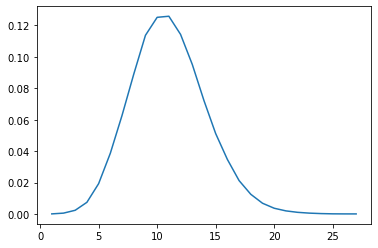

In [5]:
plt.plot(support, vals)

### Plotting the distribution

In [6]:
var = variance(support, vals)
med = median(support, vals)
print(med)
print(var)

11.0
9.984270182399998


In [7]:
print(vals)
print(support)
vals[0] = vals[0] + (1 - np.sum(vals))

[3.0000e-05 5.1000e-04 2.3300e-03 7.4000e-03 1.9270e-02 3.8630e-02
 6.2710e-02 8.8950e-02 1.1371e-01 1.2517e-01 1.2586e-01 1.1430e-01
 9.5200e-02 7.2150e-02 5.1150e-02 3.4690e-02 2.1220e-02 1.2500e-02
 6.8100e-03 3.6200e-03 1.9400e-03 1.0200e-03 5.1000e-04 2.2000e-04
 6.0000e-05 2.0000e-05 1.0000e-05 1.0000e-05]
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 27.]


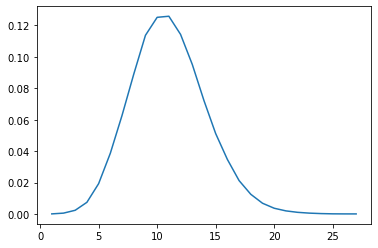

In [8]:
plt.plot(support, vals)

### Test

In [9]:
n = 6
sorted_distribution = support
weights = vals
expected_demand = np.dot(vals, support)
print(expected_demand)
max_budget = n * expected_demand

10.987760000000002


In [10]:
print(max_budget)

65.92656000000001


In [11]:
np.sum(vals)

1.0000000000000002

In [12]:
group_demands = np.random.choice(size=n, a=sorted_distribution, p=vals)
print(group_demands)

[10.  6. 10.  6. 14. 11.]


In [13]:
print(waterfilling_waste(group_demands, max_budget))

[10.  6. 10.  6. 14. 11.]


In [14]:
print(greedy(group_demands, max_budget))

[10.  6. 10.  6. 14. 11.]


In [15]:
print(constant_threshold(group_demands,max_budget,expected_demand))

[10.       6.      10.       6.      10.98776 10.98776]


In [16]:
print(waterfilling_proportional_remaining(group_demands, max_budget))

[10.  6. 10.  6. 14. 11.]


In [17]:
print(waterfilling_dynamic_waste([expected_demand for x in range(n)],group_demands,max_budget))

[10.  6. 10.  6. 14. 11.]


In [18]:
print(waterfilling_dynamic_full_waste([expected_demand for x in range(n)],group_demands,max_budget))

[10.  6. 10.  6. 14. 11.]


In [19]:
print(waterfilling_weights_waste_iid(weights, sorted_distribution, group_demands, max_budget))

[10.  6. 10.  6. 14. 11.]


In [20]:
print(weights)
print(sorted_distribution)

[3.0000e-05 5.1000e-04 2.3300e-03 7.4000e-03 1.9270e-02 3.8630e-02
 6.2710e-02 8.8950e-02 1.1371e-01 1.2517e-01 1.2586e-01 1.1430e-01
 9.5200e-02 7.2150e-02 5.1150e-02 3.4690e-02 2.1220e-02 1.2500e-02
 6.8100e-03 3.6200e-03 1.9400e-03 1.0200e-03 5.1000e-04 2.2000e-04
 6.0000e-05 2.0000e-05 1.0000e-05 1.0000e-05]
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 27.]


In [21]:
print(waterfilling_weights_full_waste_iid(weights, sorted_distribution, group_demands, max_budget))

[10.  6. 10.  6. 14. 11.]


In [22]:
print(max_min_heuristic(group_demands, [med for x in range(n)], [expected_demand for x in range(n)], [var for x in range(n)], max_budget))

[10.  6. 10.  6. 14. 11.]


# Experiments

## Varying Number of Groups

### Look at scaling with n

In [23]:
max_n = 100
num_iterations = 100
print(weights)
print(sorted_distribution)

[3.0000e-05 5.1000e-04 2.3300e-03 7.4000e-03 1.9270e-02 3.8630e-02
 6.2710e-02 8.8950e-02 1.1371e-01 1.2517e-01 1.2586e-01 1.1430e-01
 9.5200e-02 7.2150e-02 5.1150e-02 3.4690e-02 2.1220e-02 1.2500e-02
 6.8100e-03 3.6200e-03 1.9400e-03 1.0200e-03 5.1000e-04 2.2000e-04
 6.0000e-05 2.0000e-05 1.0000e-05 1.0000e-05]
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 27.]


In [24]:
expected_waterfilling_threshold = np.zeros(max_n+1)
num_iterations = 1000
for i in np.arange(2,max_n+1):
    for _ in range(num_iterations):
        budget = i * 15.
        demands = np.random.choice(size=i, a=support, p=vals)
        opt = waterfilling_waste(demands, budget)
        expected_waterfilling_threshold[i] += (1/num_iterations)*max(opt)
print(expected_waterfilling_threshold)

[ 0.      0.     12.717  13.516  14.318  14.649  15.2155 15.331  15.73
 15.891  16.125  16.239  16.442  16.604  16.769  16.793  16.927  17.093
 17.195  17.153  17.337  17.314  17.463  17.511  17.612  17.563  17.834
 17.778  17.853  17.849  18.022  18.073  18.044  18.201  18.175  18.306
 18.196  18.368  18.447  18.351  18.366  18.549  18.532  18.478  18.58
 18.533  18.624  18.644  18.687  18.7    18.83   18.79   18.931  18.887
 18.849  19.02   18.979  18.949  19.008  18.963  19.083  19.092  19.145
 19.174  19.221  19.193  19.331  19.161  19.076  19.301  19.246  19.403
 19.42   19.452  19.437  19.359  19.369  19.368  19.436  19.422  19.475
 19.564  19.548  19.554  19.576  19.52   19.646  19.558  19.805  19.639
 19.667  19.776  19.717  19.656  19.792  19.712  19.698  19.79   19.861
 19.864  19.739 ]


In [52]:
data_dict = {'NumGroups':[], 'Norm':[], 'Dynamic':[],'Weights':[], 'Adapt_Threshold':[], 'Threshold':[], 'Expected_Filling':[], 'Greedy':[], 'Dynamic_Full':[], 'Weights_Full':[], 'Max_Min_Heuristic':[]}
num_iterations = 100
for n in np.arange(2,max_n+1,1):
    n = max(int(n),1)
    group_expected_demands = np.zeros(n) + np.dot(weights, sorted_distribution)
    group_median_demands = np.zeros(n) + med
    group_variance = np.zeros(n) + var
    budget = n*expected_demand
    print(n)
    for i in range(num_iterations):
        data_dict['NumGroups'].append(n)

        
        group_demands = np.random.choice(size=n, a=support, p=vals)
        opt = waterfilling_waste(group_demands,budget)
        
        weights_sol = waterfilling_weights_waste_iid(weights, sorted_distribution, group_demands, budget)
        weights_full_sol = waterfilling_weights_full_waste_iid(weights, sorted_distribution, group_demands, budget)
        dynamic = waterfilling_dynamic_waste(group_expected_demands,group_demands,budget)
        dynamic_full = waterfilling_dynamic_full_waste(group_expected_demands, group_demands, budget)
        proportional_threshold = waterfilling_proportional_remaining(group_demands, budget)
        greed_sol = greedy(group_demands,budget)
        threshold = constant_threshold(group_demands,budget,expected_demand)
        expect_threshold = constant_threshold(group_demands, budget, expected_waterfilling_threshold[n])
        max_min_heuristic_sol = max_min_heuristic(group_demands, group_median_demands, group_expected_demands, group_variance, budget)
        
        data_dict['Norm'].append('L1')
        data_dict['Weights'].append(np.sum(np.absolute(opt - weights_sol)))
        data_dict['Dynamic'].append(np.sum(np.absolute(opt-dynamic)))
        data_dict['Adapt_Threshold'].append(np.sum(np.absolute(opt - proportional_threshold)))
        data_dict['Greedy'].append(np.sum(np.absolute(opt-greed_sol)))
        data_dict['Threshold'].append(np.sum(np.absolute(opt-threshold)))
        data_dict['Dynamic_Full'].append(np.sum(np.absolute(opt-dynamic_full)))
        data_dict['Weights_Full'].append(np.sum(np.absolute(opt-weights_full_sol)))
        data_dict['Expected_Filling'].append(np.sum(np.absolute(opt - expect_threshold)))
        data_dict['Max_Min_Heuristic'].append(np.sum(np.absolute(opt-max_min_heuristic_sol)))
        
        data_dict['NumGroups'].append(n)
        data_dict['Norm'].append('Linf')
        data_dict['Weights'].append(np.max(np.absolute(opt - weights_sol)))
        data_dict['Dynamic'].append(np.max(np.absolute(opt-dynamic)))
        data_dict['Adapt_Threshold'].append(np.max(np.absolute(opt - proportional_threshold)))
        data_dict['Greedy'].append(np.max(np.absolute(opt-greed_sol)))
        data_dict['Threshold'].append(np.max(np.absolute(opt-threshold)))
        data_dict['Dynamic_Full'].append(np.max(np.absolute(opt-dynamic_full)))
        data_dict['Weights_Full'].append(np.max(np.absolute(opt-weights_full_sol)))
        data_dict['Expected_Filling'].append(np.max(np.absolute(opt - expect_threshold)))
        data_dict['Max_Min_Heuristic'].append(np.max(np.absolute(opt-max_min_heuristic_sol)))

2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100


In [53]:
df = pd.DataFrame(data_dict).melt(id_vars=["NumGroups", 'Norm'])

In [54]:
df.to_csv('scale_with_n.csv')

In [55]:
df.columns

Index(['NumGroups', 'Norm', 'variable', 'value'], dtype='object')

In [56]:
df.rename(columns={'Number of Groups', 'Norm', 'Algorithm', 'Value'})

TypeError: 'set' object is not callable

In [ ]:
df.head

In [ ]:
filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
plt.figure(figsize=(20,10))
plt.title('Gaussian L1')
sns.lineplot(x='NumGroups', y='value', hue='variable', data=df[df.Norm == 'L1'])

In [ ]:
filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
plt.figure(figsize=(20,10))
plt.title('Gaussian Linf')
sns.lineplot(x='NumGroups', y='value', hue='variable', data=df[df.Norm == 'Linf'])

In [33]:
data_dict = {'Group':[], 'Weights_Full':[], 'Weights_Online':[],'Dynamic_Full':[], 'Dynamic_Online':[], 'True':[], 'Max_Min_Heuristic':[]}
num_iterations = 100


for i in range(num_iterations):
    max_n = 100
    
    weights = np.loadtxt('../../data/gaussian/vals_15_var_3.csv', delimiter=",")
    sorted_support = np.loadtxt('../../data/gaussian/support_15_var_3.csv', delimiter=",")
    
    expected_demands = [expected_demand for x in range(max_n)]
    median_demands = [med for _ in range(max_n)]
    variance = [var for _ in range(max_n)]
    
    # print(weights)
    # print(sorted_support)
    # print(expected_demands)
    max_budget = max_n*expected_demand
    
    
    
    group_demands = np.random.choice(size=max_n, a=sorted_support, p=weights).astype(np.float)
    print('Demands for experiment:' + str(group_demands))   
    
    dynamic_full = np.copy(expected_demands)
    dynamic_online = np.sort(np.copy(expected_demands))
    
    dynamic_online_budget = max_budget
    weights_online_budget = max_budget

    weights_online_support = np.copy(sorted_support)
    weights_online_vals = np.copy(weights)*max_n
    
    weights_full_support = np.copy(sorted_support)
    weights_full_vals = np.copy(weights)*max_n
    print('start')
    print(weights_full_vals)
    print(np.sum(weights_full_vals))
    max_min_budget = max_budget
    min_fill = 1
    
    for n in range(max_n):
        # Solve for the various waterfilling levels
        data_dict['Group'].append(n)
        
        # Adds on the true waterfilling level
        data_dict['True'].append(max(waterfilling_sorted(np.sort(np.copy(group_demands)), max_budget)))
        
        
        # Dynamic_Full
        
        # Replaces current town's demand with realized demand
        dynamic_full[n] = group_demands[n]
        # Sorts demands
        dynamic_full_sorted = np.sort(np.copy(dynamic_full))
        # Appends maximum allocation based on full demand with full budget
        data_dict['Dynamic_Full'].append(max(waterfilling_sorted(dynamic_full_sorted, max_budget)))
            
            
        # Dynamic_Online
        
        # Removes expected demand for current agent from list
        dynamic_online = delete_sorted(dynamic_online, expected_demands[n])
        
        # adds in the demand for current location
        new_sorted_list, index = insert_sorted(dynamic_online, group_demands[n])
        tmp_sol = waterfilling_sorted(new_sorted_list, dynamic_online_budget)
        data_dict['Dynamic_Online'].append(max(tmp_sol))
        # subtracts off the allocation for the next round
        dynamic_online_budget -= min(tmp_sol[index], dynamic_online_budget, group_demands[n])
        
        
        # Weights_Full
        
        # Updating the weights for the observed group
        obs_demand = group_demands[n]
        
        index = np.argmin(np.abs(weights_full_support - obs_demand))
        weights_full_vals -= weights
        weights_full_vals[index] += 1
        
        data_dict['Weights_Full'].append(max(waterfilling_sorted_weights(weights_full_support, weights_full_vals, max_budget)))
        
        
#         if n == max_n - 1:
#             print(max(waterfilling_sorted(np.sort(np.copy(group_demands)), max_budget)))
#             print(max(waterfilling_sorted_weights(weights_full_support, weights_full_vals, max_budget)))
#             print(weights_full_vals)
        
        # Weights_Online
        obs_demand = group_demands[n]
        
        index = np.argmin(np.abs(weights_online_support - obs_demand))
        weights_online_vals -= weights
        weights_online_vals[index] += 1        
        
        
        tmp_sol = waterfilling_sorted_weights(weights_online_support, weights_online_vals, weights_online_budget)
        weights_online_budget -= min(obs_demand, weights_online_budget, tmp_sol[index])
        
        weights_online_vals[index] -= 1
        data_dict['Weights_Online'].append(max(tmp_sol))
        
        # Max_Min
        
        if n == max_n - 1:
            data_dict['Max_Min_Heuristic'].append(min(max_min_budget, group_demands[n]))
        else:
            delta = (median_demands[n] - median_demands[n+1]) / ((1/2)* (median_demands[n] + median_demands[n+1]))
            budget_portion = max_min_budget * (expected_demands[n] + expected_demands[n+1]) / np.sum(expected_demands[n:])
            heuristic_threshold = budget_portion * (group_demands[n] / (group_demands[n] + median_demands[n+1] + delta * np.sqrt(variance[n+1])))
            allocation = min(heuristic_threshold, min_fill*group_demands[n], max_min_budget)
            data_dict['Max_Min_Heuristic'].append(heuristic_threshold)
            
            if allocation / group_demands[n] <= min_fill:
                min_fill = allocation / group_demands[n]
            max_min_budget -= allocation


Demands for experiment:[15.5 15.5 12.8 20.9 18.2 15.5 15.5 18.2 15.5 12.8 18.2 20.9 18.2 18.2
 12.8 20.9 18.2 23.6 15.5 18.2 12.8 18.2 15.5 18.2 20.9 18.2 12.8 12.8
 12.8 18.2 10.1 15.5 20.9 15.5 20.9 18.2 18.2 15.5 23.6 20.9 18.2 20.9
 15.5 20.9 18.2 18.2 18.2 15.5 18.2 15.5 15.5 15.5 15.5 18.2 18.2 12.8
 15.5 15.5 15.5 23.6 18.2 12.8 18.2 15.5 15.5 12.8 20.9 15.5 18.2 15.5
 20.9 12.8 15.5 18.2 18.2 20.9  7.4 12.8 15.5 12.8 10.1 18.2 18.2 18.2
 12.8 12.8 18.2 12.8 18.2 15.5 15.5 18.2 10.1 15.5 15.5 15.5 18.2 12.8
 12.8 18.2]
start
[0.0000e+00 3.3000e-02 5.3400e-01 4.5740e+00 1.8204e+01 3.3487e+01
 2.8992e+01 1.1717e+01 2.2520e+00 2.0000e-01 7.0000e-03]
100.00000000000001
Demands for experiment:[15.5 12.8 12.8 12.8 18.2 15.5 18.2 12.8 23.6 18.2 18.2 18.2 15.5 10.1
 18.2 18.2 18.2 20.9 15.5 15.5 12.8 15.5 20.9 18.2 12.8  4.7 12.8 18.2
 15.5 10.1 12.8 12.8 15.5 20.9 12.8 20.9 15.5 18.2 15.5 18.2 12.8 20.9
 10.1 10.1 18.2 20.9 15.5 15.5 12.8 20.9 15.5 18.2 18.2 15.5 15.5 18.2
 15.5 15.5 1

 18.2 18.2]
start
[0.0000e+00 3.3000e-02 5.3400e-01 4.5740e+00 1.8204e+01 3.3487e+01
 2.8992e+01 1.1717e+01 2.2520e+00 2.0000e-01 7.0000e-03]
100.00000000000001
Demands for experiment:[15.5 15.5 12.8 12.8 15.5 18.2 18.2 15.5 18.2 18.2 12.8 20.9 15.5 12.8
 18.2 12.8 15.5 18.2 18.2 12.8 12.8 18.2 18.2 12.8 15.5 20.9 15.5 18.2
 15.5 15.5 18.2 18.2 12.8 18.2 18.2 18.2 12.8 18.2 15.5 15.5 15.5 18.2
 12.8 10.1 20.9 18.2 15.5 18.2 12.8 12.8 15.5 18.2 15.5 15.5 18.2 15.5
 15.5 20.9 12.8 15.5 12.8 15.5 20.9 18.2 10.1 18.2 10.1 12.8 23.6 15.5
 15.5 23.6 15.5 15.5 18.2 15.5 18.2 15.5 18.2 18.2 23.6 20.9 15.5 15.5
 15.5 18.2 12.8 18.2 12.8 20.9 15.5 18.2 20.9 18.2 18.2 15.5 18.2 12.8
 20.9 15.5]
start
[0.0000e+00 3.3000e-02 5.3400e-01 4.5740e+00 1.8204e+01 3.3487e+01
 2.8992e+01 1.1717e+01 2.2520e+00 2.0000e-01 7.0000e-03]
100.00000000000001
Demands for experiment:[18.2 12.8 12.8 18.2 18.2 20.9 18.2 18.2 18.2 12.8 23.6 15.5 15.5 18.2
 18.2 12.8 18.2 15.5 15.5 12.8 20.9 15.5 18.2 15.5 10.1 15.5 15.

 15.5 12.8]
start
[0.0000e+00 3.3000e-02 5.3400e-01 4.5740e+00 1.8204e+01 3.3487e+01
 2.8992e+01 1.1717e+01 2.2520e+00 2.0000e-01 7.0000e-03]
100.00000000000001
Demands for experiment:[15.5 18.2 12.8 18.2 12.8 18.2 15.5 18.2 15.5 15.5 12.8 12.8 20.9 18.2
 18.2 15.5 10.1 18.2 15.5 15.5 15.5 18.2 15.5 18.2 18.2 12.8 20.9 15.5
 18.2 18.2 15.5 20.9 15.5 15.5 18.2 15.5 18.2 20.9 15.5 15.5 15.5 15.5
 20.9 15.5 15.5 15.5 12.8 18.2 20.9  7.4 20.9 18.2 12.8 18.2 15.5 18.2
 18.2 20.9 15.5 15.5 18.2 18.2 15.5 20.9 12.8 15.5 18.2 18.2 10.1 15.5
 15.5 12.8 15.5 18.2 12.8 10.1 20.9 20.9 20.9 15.5 15.5 18.2 12.8 18.2
 15.5 15.5 10.1 12.8 18.2 15.5 12.8 20.9 18.2 18.2 23.6 15.5 18.2 18.2
 15.5 20.9]
start
[0.0000e+00 3.3000e-02 5.3400e-01 4.5740e+00 1.8204e+01 3.3487e+01
 2.8992e+01 1.1717e+01 2.2520e+00 2.0000e-01 7.0000e-03]
100.00000000000001
Demands for experiment:[15.5 20.9 18.2 12.8 12.8 15.5 15.5 20.9 20.9 20.9 23.6 12.8 15.5 12.8
 18.2 12.8 18.2 20.9 20.9 12.8 15.5 15.5 20.9 20.9 18.2 23.6 15.

 12.8 15.5]
start
[0.0000e+00 3.3000e-02 5.3400e-01 4.5740e+00 1.8204e+01 3.3487e+01
 2.8992e+01 1.1717e+01 2.2520e+00 2.0000e-01 7.0000e-03]
100.00000000000001
Demands for experiment:[15.5 18.2 10.1 10.1 20.9 15.5 15.5 15.5 20.9 12.8 15.5 15.5 18.2 18.2
 15.5 18.2 18.2 15.5 20.9 15.5 15.5 18.2 20.9 20.9 18.2 18.2 18.2 12.8
 15.5 15.5 10.1 15.5 15.5 18.2 18.2 20.9 23.6 15.5 15.5 20.9 15.5 15.5
 15.5 18.2 20.9 18.2 18.2 18.2 18.2 12.8 18.2 18.2 18.2 18.2 23.6 15.5
 12.8 12.8 18.2 15.5 12.8 15.5 18.2 15.5 20.9 20.9 18.2 18.2 12.8 15.5
 12.8 12.8 12.8 15.5 20.9 20.9 20.9 18.2 18.2 18.2 12.8 18.2 15.5 15.5
 12.8 18.2 15.5 10.1 12.8 15.5 15.5 12.8 12.8 18.2 15.5 15.5 12.8 15.5
 18.2 15.5]
start
[0.0000e+00 3.3000e-02 5.3400e-01 4.5740e+00 1.8204e+01 3.3487e+01
 2.8992e+01 1.1717e+01 2.2520e+00 2.0000e-01 7.0000e-03]
100.00000000000001
Demands for experiment:[15.5 18.2 10.1 20.9 15.5 18.2 18.2 15.5 15.5 15.5 12.8 10.1 18.2 18.2
 15.5 18.2 18.2 18.2 18.2 15.5 15.5 12.8 15.5 12.8 12.8 15.5 18.

Demands for experiment:[15.5 12.8 12.8 15.5 15.5 15.5 20.9 18.2 18.2 15.5 20.9 12.8 18.2 18.2
 15.5 15.5 15.5 15.5 20.9 15.5 15.5 15.5 18.2 12.8 12.8 12.8 15.5 15.5
 18.2 15.5 15.5 15.5 15.5 12.8 15.5 18.2 18.2 15.5 15.5 18.2 18.2 15.5
 12.8 18.2 23.6 15.5 20.9 18.2 18.2 20.9 18.2 18.2 15.5 18.2 20.9 18.2
 15.5 12.8 15.5 18.2 15.5 15.5 15.5 12.8 15.5 18.2 18.2 18.2 18.2 12.8
 18.2 15.5 15.5 18.2 20.9 18.2 20.9 18.2 23.6 15.5 10.1 12.8 18.2 18.2
 18.2 15.5 12.8 20.9 15.5 20.9 18.2 15.5 15.5 18.2 15.5 12.8 18.2 20.9
 20.9 20.9]
start
[0.0000e+00 3.3000e-02 5.3400e-01 4.5740e+00 1.8204e+01 3.3487e+01
 2.8992e+01 1.1717e+01 2.2520e+00 2.0000e-01 7.0000e-03]
100.00000000000001
Demands for experiment:[18.2 20.9 15.5 20.9 15.5 12.8 12.8 20.9 18.2 15.5 18.2 20.9 15.5 12.8
 15.5 12.8 10.1 12.8 18.2 15.5 12.8 15.5 18.2 10.1 18.2 15.5 18.2 18.2
 15.5 18.2 15.5 23.6 18.2 10.1 15.5 10.1 12.8 10.1 10.1 18.2 15.5 15.5
 18.2 12.8 12.8 18.2 12.8 20.9 20.9 18.2 18.2 18.2 15.5 18.2 12.8 10.1
 18.2 23.6 1

 15.5 12.8]
start
[0.0000e+00 3.3000e-02 5.3400e-01 4.5740e+00 1.8204e+01 3.3487e+01
 2.8992e+01 1.1717e+01 2.2520e+00 2.0000e-01 7.0000e-03]
100.00000000000001
Demands for experiment:[10.1 18.2 18.2 18.2 18.2 15.5 15.5 15.5 18.2 15.5  7.4 20.9 18.2 20.9
 10.1 12.8 20.9 20.9 15.5 15.5 20.9 15.5 18.2 15.5 15.5 15.5 18.2 15.5
 20.9 15.5 15.5 12.8 15.5 12.8 18.2 12.8 15.5 15.5 15.5 15.5 12.8 12.8
 18.2 15.5 12.8 12.8 15.5 10.1 18.2 10.1 10.1 15.5 15.5 18.2 18.2 18.2
 12.8 18.2 10.1 15.5 15.5 15.5 18.2 12.8 15.5 12.8 15.5 12.8 15.5 23.6
 18.2 15.5 20.9 18.2 18.2 18.2  7.4 18.2 15.5 15.5 15.5 20.9 18.2 18.2
 12.8 20.9 15.5 20.9 12.8 18.2 20.9 18.2 18.2 18.2 10.1 15.5 12.8 18.2
 15.5 18.2]
start
[0.0000e+00 3.3000e-02 5.3400e-01 4.5740e+00 1.8204e+01 3.3487e+01
 2.8992e+01 1.1717e+01 2.2520e+00 2.0000e-01 7.0000e-03]
100.00000000000001
Demands for experiment:[15.5 15.5 15.5 20.9 18.2 12.8 15.5 20.9 18.2 15.5 18.2 18.2 15.5 15.5
 15.5 20.9 15.5 15.5 12.8 12.8 10.1 20.9 15.5 12.8 18.2 15.5 12.

Demands for experiment:[12.8 18.2 15.5 15.5 12.8 18.2 18.2 12.8 15.5 20.9 15.5 20.9 15.5 15.5
 15.5 18.2 18.2 12.8 23.6 20.9 20.9 12.8 15.5 18.2 18.2 20.9 15.5 10.1
 15.5 18.2 15.5 15.5 18.2 20.9 12.8 15.5 15.5 12.8 18.2 15.5 12.8 12.8
 18.2 10.1 18.2 18.2 12.8 12.8 12.8 18.2 18.2 10.1 15.5 15.5 12.8 10.1
 10.1 18.2 23.6 18.2 20.9 20.9 12.8 15.5 15.5 10.1 20.9 20.9 18.2 18.2
 12.8 18.2 10.1 12.8 15.5 18.2 12.8 12.8 18.2 15.5 12.8 18.2 12.8 18.2
 18.2 10.1 18.2 18.2 15.5 12.8 15.5 15.5 15.5 18.2 18.2 20.9 12.8 18.2
 15.5 18.2]
start
[0.0000e+00 3.3000e-02 5.3400e-01 4.5740e+00 1.8204e+01 3.3487e+01
 2.8992e+01 1.1717e+01 2.2520e+00 2.0000e-01 7.0000e-03]
100.00000000000001
Demands for experiment:[18.2 15.5 15.5 12.8 18.2 18.2 18.2 18.2 20.9 18.2 18.2 15.5 18.2 20.9
 18.2 15.5 20.9 12.8 12.8 12.8 18.2 15.5 18.2 20.9 18.2 15.5 20.9 18.2
 18.2 18.2 12.8 12.8 18.2 12.8 15.5 15.5 12.8 15.5 20.9 18.2 15.5 20.9
 18.2 12.8 15.5 15.5 18.2  7.4 15.5 18.2 18.2 12.8 10.1 15.5 18.2 12.8
 15.5  7.4 1

In [34]:
np.std(data_dict['True'])

0.03489512101628529

In [35]:
df = pd.DataFrame(data_dict).melt(id_vars="Group")

In [36]:
df.to_csv('comparison_of_waterfilling_levels.csv')

Text(0.5, 0, 'Estimated Level')

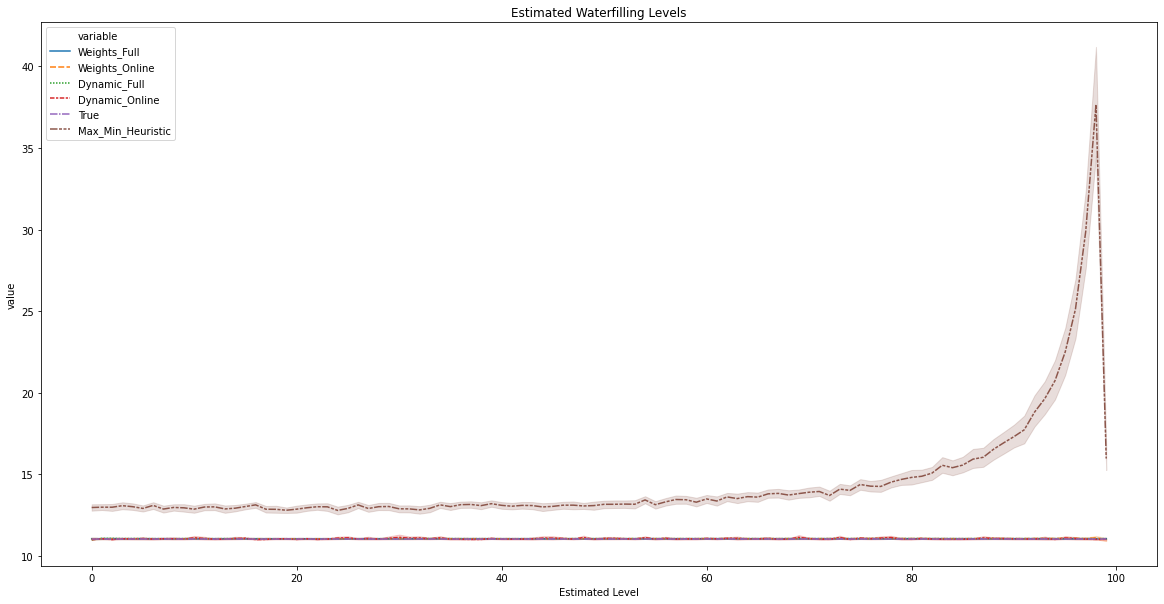

In [37]:
plt.figure(figsize=(20,10))
sns.lineplot(x='Group', y='value', style='variable', hue = 'variable', data=df)
plt.title('Estimated Waterfilling Levels')
plt.xlabel('Estimated Level')

### Calculating Fairness Statistics


In [38]:
num_iterations = 1000
weights = np.loadtxt('../../data/gaussian/vals_15_var_3.csv', delimiter=",")
sorted_distribution = np.loadtxt('../../data/gaussian/support_15_var_3.csv', delimiter=",")
expected_demand = np.dot(weights, sorted_distribution)
n=100

In [39]:
group = np.arange(n)
group_expected_demands = np.zeros(n) + expected_demand
budget = expected_demand*n
score_weights_online = np.zeros((n,num_iterations))
score_weights_full = np.zeros((n,num_iterations))
score_dynamic_online = np.zeros((n,num_iterations))
score_dynamic_full = np.zeros((n,num_iterations))
score_greedy = np.zeros((n,num_iterations))
score_adapt_threshold = np.zeros((n,num_iterations))
score_fixed_threshold = np.zeros((n,num_iterations))
score_expect_threshold = np.zeros((n, num_iterations))
score_max_min = np.zeros((n, num_iterations))

# 8 different algorithms
env = np.zeros((9,num_iterations))
po = np.zeros((9,num_iterations))
prop = np.zeros((9,num_iterations))
linf = np.zeros((9,num_iterations))
max_min = np.zeros((9, num_iterations))
for i in range(num_iterations):
    budget = n*np.dot(weights, sorted_distribution)

        
    group_demands = np.random.choice(size=n, a=sorted_distribution, p=weights)
    group_median_demands = np.zeros(n) + med
    group_variance = np.zeros(n) + var
    
    opt = waterfilling_waste(group_demands,budget)

    weights_sol = waterfilling_weights_waste_iid(weights, sorted_distribution, group_demands, budget)
    weights_full_sol = waterfilling_weights_full_waste_iid(weights, sorted_distribution, group_demands, budget)
    dynamic = waterfilling_dynamic_waste(group_expected_demands,group_demands,budget)
    dynamic_full = waterfilling_dynamic_full_waste(group_expected_demands, group_demands, budget)
    proportional_threshold = waterfilling_proportional_remaining(group_demands, budget)
    greedy_sol = greedy(group_demands,budget)
    threshold = constant_threshold(group_demands,budget,expected_demand)
    expect_threshold = constant_threshold(group_demands, budget, expected_waterfilling_threshold[n])
    max_min_heuristic_sol = max_min_heuristic(group_demands, group_median_demands, group_expected_demands, group_variance, budget)

    # comparing weights_online
    
    score_weights_online[:,i] = opt - weights_sol
    env[0,i] = max(0,np.amax(envy_utility(weights_sol,group_demands)))
    po[0,i] = excess(weights_sol,budget)
    prop[0,i] = np.amax(proportionality_utility(weights_sol,group_demands,budget))
    max_min[0,i] = np.min(utility_ratio(weights_sol, group_demands, budget))
    linf[0,i] = np.amax(score_weights_online[:,i])
    
    
    # comparing weights_full
    
    score_weights_full[:,i] = opt - weights_full_sol
    env[1,i] = max(0,np.amax(envy_utility(weights_full_sol,group_demands)))
    po[1,i] = excess(weights_full_sol,budget)
    prop[1,i] = np.amax(proportionality_utility(weights_full_sol,group_demands,budget))
    max_min[1,i] = np.min(utility_ratio(weights_full_sol, group_demands, budget))
    linf[1,i] = np.amax(score_weights_full[:,i])
    
    
    # comparing dynamic_online
    
    score_dynamic_online[:,i] = opt - dynamic
    env[2,i] = max(0,np.amax(envy_utility(dynamic,group_demands)))
    po[2,i] = excess(dynamic,budget)
    prop[2,i] = np.amax(proportionality_utility(dynamic,group_demands,budget))
    max_min[2,i] = np.min(utility_ratio(dynamic, group_demands, budget))
    linf[2,i] = np.amax(score_dynamic_online[:,i])
    
    
    # comparing dynamic_full
    
    score_dynamic_full[:,i] = opt - dynamic_full
    env[3,i] = max(0,np.amax(envy_utility(dynamic_full,group_demands)))
    po[3,i] = excess(dynamic_full,budget)
    prop[3,i] = np.amax(proportionality_utility(dynamic_full,group_demands,budget))
    max_min[3,i] = np.min(utility_ratio(dynamic_full, group_demands, budget))
    linf[3,i] = np.amax(score_dynamic_full[:,i])
    
    
    # comparing greedy
    
    score_greedy[:,i] = opt - greedy_sol
    env[4,i] = max(0,np.amax(envy_utility(greedy_sol,group_demands)))
    po[4,i] = excess(greedy_sol,budget)
    prop[4,i] = np.amax(proportionality_utility(greedy_sol,group_demands,budget))
    max_min[4,i] = np.min(utility_ratio(greedy_sol, group_demands, budget))
    linf[4,i] = np.amax(score_greedy[:,i])
    
    # comparing fixed_threshold
    
    score_fixed_threshold[:,i] = opt - threshold
    env[5,i] = max(0,np.amax(envy_utility(threshold,group_demands)))
    po[5,i] = excess(threshold,budget)
    prop[5,i] = np.amax(proportionality_utility(threshold,group_demands,budget))
    max_min[5,i] = np.min(utility_ratio(threshold, group_demands, budget))
    linf[5,i] = np.amax(score_fixed_threshold[:,i])    
    
    
    # comparing adaptive_threshold
    
    score_adapt_threshold[:,i] = opt - proportional_threshold
    env[6,i] = max(0,np.amax(envy_utility(proportional_threshold,group_demands)))
    po[6,i] = excess(proportional_threshold,budget)
    prop[6,i] = np.amax(proportionality_utility(proportional_threshold,group_demands,budget))
    max_min[6,i] = np.min(utility_ratio(proportional_threshold, group_demands, budget))
    linf[6,i] = np.amax(score_adapt_threshold[:,i])    

    # comparing expected_threshold
    
    score_expect_threshold[:,i] = opt - expect_threshold
    env[7,i] = max(0,np.amax(envy_utility(expect_threshold,group_demands)))
    po[7,i] = excess(expect_threshold,budget)
    prop[7,i] = np.amax(proportionality_utility(expect_threshold,group_demands,budget))
    max_min[7,i] = np.min(utility_ratio(expect_threshold, group_demands, budget))
    linf[7,i] = np.amax(score_expect_threshold[:,i])    
    

    # comparing max_min_heurstic
    
    score_max_min[:,i] = opt - max_min_heuristic_sol
    env[8,i] = max(0,np.amax(envy_utility(max_min_heuristic_sol,group_demands)))
    po[8,i] = excess(max_min_heuristic_sol,budget)
    prop[8,i] = np.amax(proportionality_utility(max_min_heuristic_sol,group_demands,budget))
    max_min[8,i] = np.min(utility_ratio(max_min_heuristic_sol, group_demands, budget))
    linf[8,i] = np.amax(score_max_min[:,i]) 

In [40]:
score_weights_online = np.average(score_weights_online, axis=1)
score_weights_full = np.average(score_weights_full, axis=1)
score_dynamic_online = np.average(score_dynamic_online, axis=1)
score_dynamic_full = np.average(score_dynamic_full, axis=1)
score_greedy = np.average(score_greedy, axis=1)
score_adapt_threshold = np.average(score_adapt_threshold, axis=1)
score_fixed_threshold = np.average(score_fixed_threshold, axis=1)
score_expect_threshold = np.average(score_expect_threshold, axis=1)
score_max_min = np.average(score_max_min, axis=1)

env = np.average(env,axis=1)
po = np.average(po,axis=1)
prop = np.average(prop,axis=1)
linf = np.average(linf,axis=1)
max_min = np.average(max_min, axis=1)

In [41]:
print(env)

[0.11611143 0.27067956 0.20145695 0.19412496 0.39918384 0.
 0.2210658  0.12517092 0.06612837]


In [42]:
print(po)

[0.1522568  0.13960614 0.22564749 0.23656851 0.1194568  1.25671122
 0.70649213 0.26175607 0.65106035]


In [43]:
print(prop)

[1.07421108e-02 2.19025886e-01 6.43929354e-16 6.62596055e-02
 3.75260977e-01 0.00000000e+00 1.99840144e-18 1.13560439e-01
 6.39175262e-02]


In [44]:
print(max_min)

[0.86139853 0.70846972 0.78906262 0.77085643 0.6007135  0.68503387
 0.71590082 0.73200565 0.93382925]


In [45]:
print(linf)

[2.10301808 4.7789749  3.55512372 3.80612597 6.66509767 5.65293866
 5.12940119 4.50457376 1.35111073]


In [46]:
print('weights_online, weights_full, dynamic_online, dynamic_full, greedy, fixed_threshold, adaptive_threshold, expected_threshold, max_min')
print('envy:')
print(env)
print('po')
print(po)
print('prop')
print(prop)
print('sum')
print(env+po+prop)
print('max_min')
print(max_min)
print('linf')
print(linf)

weights_online, weights_full, dynamic_online, dynamic_full, greedy, fixed_threshold, adaptive_threshold, expected_threshold, max_min
envy:
[0.11611143 0.27067956 0.20145695 0.19412496 0.39918384 0.
 0.2210658  0.12517092 0.06612837]
po
[0.1522568  0.13960614 0.22564749 0.23656851 0.1194568  1.25671122
 0.70649213 0.26175607 0.65106035]
prop
[1.07421108e-02 2.19025886e-01 6.43929354e-16 6.62596055e-02
 3.75260977e-01 0.00000000e+00 1.99840144e-18 1.13560439e-01
 6.39175262e-02]
sum
[0.27911035 0.62931159 0.42710444 0.49695307 0.89390162 1.25671122
 0.92755793 0.50048743 0.78110624]
max_min
[0.86139853 0.70846972 0.78906262 0.77085643 0.6007135  0.68503387
 0.71590082 0.73200565 0.93382925]
linf
[2.10301808 4.7789749  3.55512372 3.80612597 6.66509767 5.65293866
 5.12940119 4.50457376 1.35111073]


In [47]:
data_dict = {'Group':group, 'Weights_Online': score_weights_online, 'Weights_Full':score_weights_full, 'Dynamic_Online':score_dynamic_online, 'Dynamic_Full':score_dynamic_full, 'Greedy':score_greedy, 'Adapt_Threshold': score_adapt_threshold, 'Fixed_Threshold': score_fixed_threshold, 'Expect_Threshold':score_expect_threshold, 'Max_Min_Heuristic':score_max_min}
df_uniform = pd.DataFrame(data_dict).melt(id_vars="Group")

In [48]:
df_uniform.columns

Index(['Group', 'variable', 'value'], dtype='object')

In [49]:
df_uniform.to_csv('fairness_group_by_group.csv')

Text(0.5, 0, 'Estimated Level')

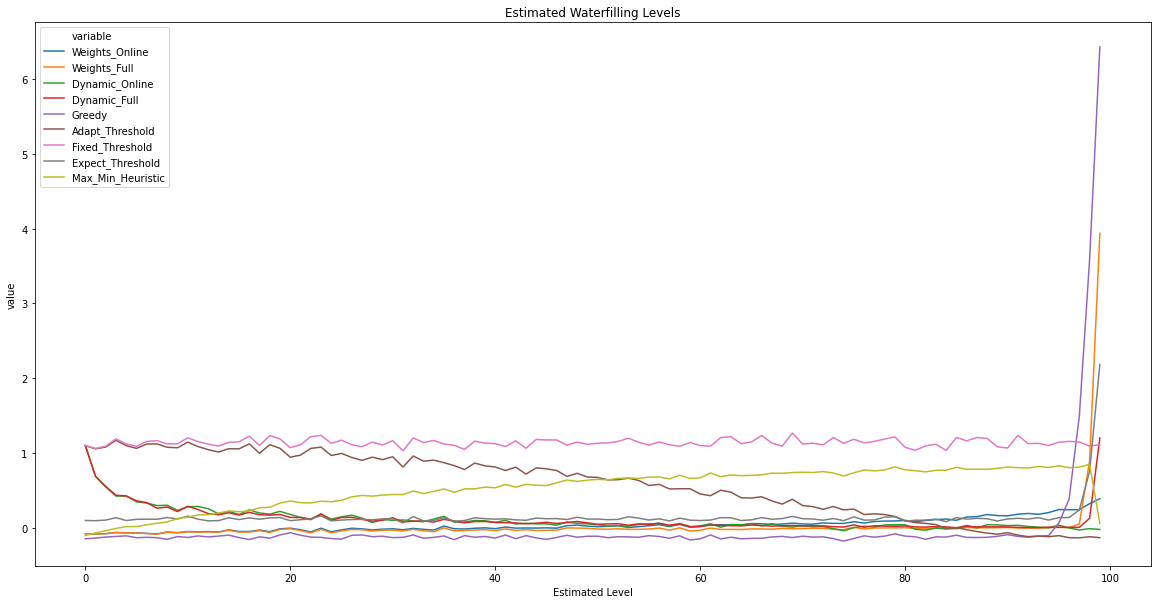

In [50]:
plt.figure(figsize=(20,10))
sns.lineplot(x='Group', y='value', hue = 'variable', data=df_uniform)
plt.title('Estimated Waterfilling Levels')
plt.xlabel('Estimated Level')